## 5. Gene Embedding Analysis Tutorial

Uses the **full-atlas** PerturbGen extract already on sod2
(`masking_original_paper/embeddings_full_atlas`, 16 Aug).
Do not re-run notebook 4 dump unless that h5ad is missing.


In this notebook, we explore gene embeddings as a framework for de novo gene program discovery. Genes grouped into the same program may represent coordinated biological functions and can serve as candidate targets for downstream perturbation studies.

We use the AnnData from Notebook 4:
- **cell embeddings** in `adata.obsm['cls_embeddings']`
- **gene embeddings** per LPS timepoint in `adata.varm` (`90m_LPS`, `6h_LPS`, `10h_LPS`)

This is the **full-atlas** extract: every unique `cell_pairing_index` in the MaskGIT dump, gene times in `varm`. No train/val/test filter in this notebook.


Load the libraries

In [1]:
import scanpy as sc
import matplotlib as mpl
import numpy as np
import pandas as pd
import anndata as ad
import gseapy as gp
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

### Config — paths for this analysis

`EMB_H5AD` = full-atlas cell + gene embeddings (notebook 4 dump, all pairings).  
`FULL_H5AD` = entire LPS paired expression object (all times; UMAP / violins).  
`GENE_NAME_ID_DICT` = Geneformer symbol↔Ensembl map (for readable gene names).


In [2]:
from pathlib import Path
import pickle
import scanpy as sc

WORKSPACE = Path("/home/stuke1/perturbgen")
SOD2 = Path("/mnt/sod2-project/csb4/stuke1/perturbgen")

# Existing full-atlas extract (notebook 4 already dumped this).
EMB_DIR = SOD2 / "T_perturb" / "res" / "masking_original_paper" / "embeddings_full_atlas"
EMB_H5AD = EMB_DIR / "20260816-14:10_inference_embs_t[1, 2, 3]_scmaskgit_mpow.h5ad"

# Gene-program figures live next to this atlas extract.
RESULTS_DIR = EMB_DIR / "gene_program_discovery"
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# LPS expression AnnData (for optional expression UMAP / violin plots)
FULL_H5AD = (
    WORKSPACE
    / "T_perturb"
    / "tokenized_data"
    / "LPS_all_tps_2k"
    / "h5ad_pairing_2000_hvg_GF_genes"
    / "LPS_all_tps_2k.h5ad"
)

# Ensembl -> gene symbol (Geneformer)
GENE_NAME_ID_DICT = Path(
    "/mnt/sod2-project/csb4/stuke1/Geneformer/geneformer/gene_name_id_dict.pkl"
)

for p in (EMB_H5AD, FULL_H5AD, GENE_NAME_ID_DICT):
    assert Path(p).is_file(), f"missing: {p}"

print("EMB_DIR:", EMB_DIR)
print("EMB_H5AD:", EMB_H5AD)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIG_DIR:", FIG_DIR)
print("FULL_H5AD:", FULL_H5AD)
if (EMB_DIR / "ckpt_info.txt").is_file():
    print("--- ckpt_info ---")
    print((EMB_DIR / "ckpt_info.txt").read_text())

adata = sc.read(EMB_H5AD)
print(adata)
print("obsm:", list(adata.obsm.keys()), "| varm:", list(adata.varm.keys()))
print("n_embedding_cells (unique pairing):", adata.n_obs)
assert "embeddings_full_atlas" in str(EMB_H5AD), EMB_H5AD
assert "benchmark_test" not in str(EMB_H5AD), "refusing test-split extract"


EMB_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_original_paper/embeddings_full_atlas
EMB_H5AD: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_original_paper/embeddings_full_atlas/20260816-14:10_inference_embs_t[1, 2, 3]_scmaskgit_mpow.h5ad
RESULTS_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_original_paper/embeddings_full_atlas/gene_program_discovery
FIG_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_original_paper/embeddings_full_atlas/gene_program_discovery/figures
FULL_H5AD: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_GF_genes/LPS_all_tps_2k.h5ad
AnnData object with n_obs × n_vars = 69531 × 1856
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'
    var: 'token_id'
    obsm: 'cls_embeddings'
    varm: '10h_LPS', '6h_LPS', '90m_LPS'
obsm: ['cls_embeddings'] | varm: ['10h_LPS', '6h_LPS', '90m_LPS']


For each timepoint, the model provides gene embeddings stored in varm, while cell embeddings are available under cls_embeddings.

In [3]:
print(adata)
print("obsm keys:", list(adata.obsm.keys()))
print("varm keys:", list(adata.varm.keys()))

AnnData object with n_obs × n_vars = 69531 × 1856
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'
    var: 'token_id'
    obsm: 'cls_embeddings'
    varm: '10h_LPS', '6h_LPS', '90m_LPS'
obsm keys: ['cls_embeddings']
varm keys: ['10h_LPS', '6h_LPS', '90m_LPS']


In [4]:
# Gene embeddings by timepoint
for tp in ["90m_LPS", "6h_LPS", "10h_LPS"]:
    g = adata.varm[tp]
    print(tp, g.shape)                     # (n_genes, d_model)
    print(g[:3, :8])                       # first 3 genes, first 8 dims               # first 3 cells, first 8 dims           # first 3 cells, first 8 dims

90m_LPS (1856, 768)
[[-0.31323186  0.67484176  0.18284999 -0.0555098   0.82456315 -0.02259315
  -0.09661126 -0.2428353 ]
 [ 0.2291723   0.00244853  0.17068636  1.1655765   2.2816174   0.5559569
   0.43309942 -0.05770594]
 [-0.28872386 -0.05333414  0.9814639  -0.01143415  0.3155987   0.93537664
   0.40571597  0.05121452]]
6h_LPS (1856, 768)
[[ 0.17659141 -0.9911327   0.15433297 -0.92068857  1.1174128  -0.63531846
   0.420711   -0.14310154]
 [ 0.09430343 -1.1532383   0.06115799  0.12251735  1.8824794   0.09204599
   0.6138664  -0.5900371 ]
 [-0.12300781 -0.45034507  1.2427762  -0.47335783 -0.02489081  0.8220615
   0.4852446   0.08961424]]
10h_LPS (1856, 768)
[[ 6.3340005e-04 -9.8768696e-02  2.9055768e-01 -3.6624825e-01
   5.3732896e-01 -2.3745191e-01  5.1418595e-02 -1.7870349e-01]
 [ 2.4019538e-01 -2.8254086e-01  2.1609990e-02  6.4211154e-01
   1.9810342e+00  2.4523962e-01  2.7617347e-01 -2.3991300e-01]
 [ 4.4550125e-02  1.6512930e-01  1.3069645e+00  1.5093075e-01
   7.5745481e-01  4.278

Optionally, cell type labels are renamed for consistency. Cell embeddings can then be used for neighborhood graph construction and UMAP visualization.

In [5]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata.obs['cell_type_harmonized'] = adata.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata.obs['cell_type_harmonized'].cat.categories}
)

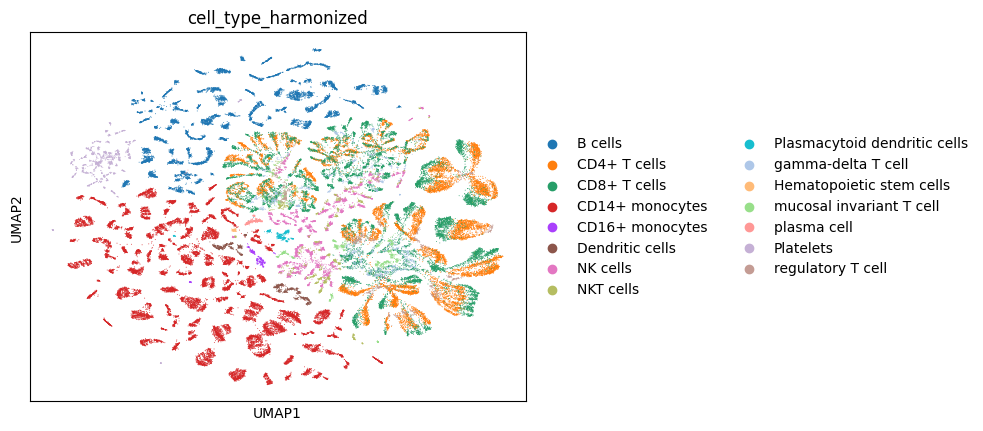

In [6]:
sc.pp.neighbors(adata,use_rep='cls_embeddings') # compute the neighborhood graph
sc.tl.umap(adata) # compute the UMAP coordinates
sc.pl.umap(adata,color='cell_type_harmonized') # plot the UMAP with cell type coloring

Load the LPS paired AnnData for (1) Ensembl→symbol mapping and (2) optional expression-space UMAP / program violin plots.


In [7]:
adata_full = sc.read(FULL_H5AD)
print(adata_full)
print("var columns:", list(adata_full.var.columns))
print("n_expression_cells (all LPS times, no split):", adata_full.n_obs)


AnnData object with n_obs × n_vars = 223478 × 1856
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

We normalize and log-transform the original AnnData object to generate a baseline UMAP visualization. This optional step serves primarily as a comparison to the UMAP derived from PerturbGen cell embeddings.

In [8]:
sc.pp.normalize_total(adata_full) # normalize the data
sc.pp.log1p(adata_full) # log-transform the data

In [9]:
sc.pp.pca(adata_full)
sc.pp.neighbors(adata_full, use_rep="X_pca")
sc.tl.umap(adata_full)

In [11]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata_full.obs['cell_type_harmonized'] = adata_full.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata_full.obs['cell_type_harmonized'].cat.categories}
)


In [12]:
sc.set_figure_params(dpi_save=600) # set high dpi for saved figures

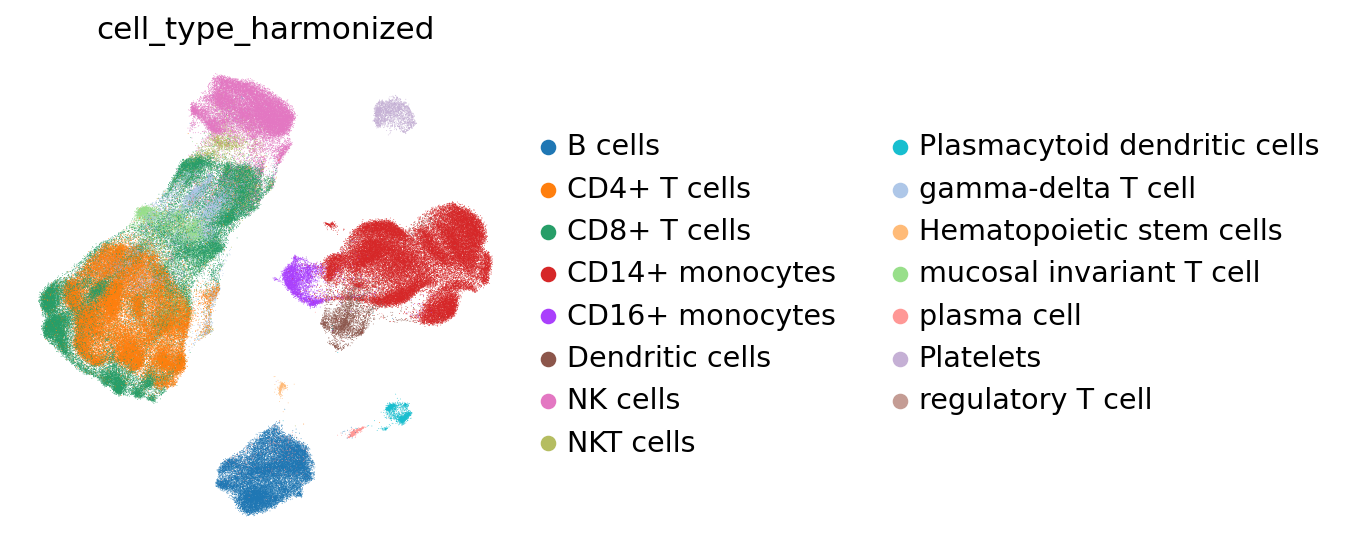

In [13]:

mpl.rcParams.update({ # set global matplotlib parameters
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

sc.pl.umap( # plot UMAP of full data
    adata_full,
    color='cell_type_harmonized',
    frameon=False,
    save='_umapcelltype.png'  
)


In [14]:
adata_full

AnnData object with n_obs × n_vars = 223478 × 1856
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

Map Ensembl IDs in the embedding object to gene symbols via Geneformer's `gene_name_id_dict` (symbol→Ensembl), reversed.


In [15]:
with open(GENE_NAME_ID_DICT, "rb") as f:
    symbol_to_ensembl = pickle.load(f)
ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

adata.var["gene_symbol"] = [
    ensembl_to_symbol.get(g, g) for g in adata.var_names.astype(str)
]
n_sym = sum(1 for g, s in zip(adata.var_names, adata.var["gene_symbol"]) if g != s)
print(f"Mapped {n_sym}/{adata.n_vars} Ensembl IDs to gene symbols (embeddings)")

# Same mapping on expression AnnData (used later for score_genes)
if "ensembl_id" in adata_full.var.columns:
    full_ids = adata_full.var["ensembl_id"].astype(str)
elif "gene_ids-0" in adata_full.var.columns:
    full_ids = adata_full.var["gene_ids-0"].astype(str)
else:
    full_ids = pd.Index(adata_full.var_names.astype(str))
adata_full.var["gene_symbol"] = [ensembl_to_symbol.get(g, g) for g in full_ids]
n_full = sum(
    1 for g, s in zip(full_ids, adata_full.var["gene_symbol"]) if g != s
)
print(f"Mapped {n_full}/{adata_full.n_vars} Ensembl IDs to gene symbols (adata_full)")
adata.var[["gene_symbol"]].head()


Mapped 1855/1856 Ensembl IDs to gene symbols (embeddings)
Mapped 1855/1856 Ensembl IDs to gene symbols (adata_full)


,gene_symbol
ENSG00000188290,HES4
ENSG00000187608,ISG15
ENSG00000186891,TNFRSF18
ENSG00000186827,TNFRSF4
ENSG00000189409,MMP23B


We construct a new AnnData object in which each gene is treated as an observation (analogous to a cell), and its features correspond to a n(here =768)-dimensional learned embedding vector rather than expression values. This representation enables standard single-cell analysis workflows, such as UMAP visualization and clustering, to be directly applied to gene embeddings.

In [16]:
gene_symbols = adata.var['gene_symbol'].values
timepoints = list(adata.varm.keys())

all_embeddings = []
obs_names = []
obs_timepoints = []
obs_genes = []

for tp in timepoints:
    embedding = adata.varm[tp]  
    all_embeddings.append(embedding)
    
    obs_names.extend([f"{g}_{tp}" for g in gene_symbols])
    obs_genes.extend(gene_symbols)
    obs_timepoints.extend([tp] * len(gene_symbols))

X = np.vstack(all_embeddings)

obs = pd.DataFrame({
    "gene_symbol": obs_genes,
    "timepoint": obs_timepoints
}, index=obs_names)

new_adata = ad.AnnData(X=X, obs=obs)

In [17]:
new_adata.obs

,gene_symbol,timepoint
HES4_10h_LPS,HES4,10h_LPS
ISG15_10h_LPS,ISG15,10h_LPS
TNFRSF18_10h_LPS,TNFRSF18,10h_LPS
TNFRSF4_10h_LPS,TNFRSF4,10h_LPS
MMP23B_10h_LPS,MMP23B,10h_LPS
...,...,...
MPP1_90m_LPS,MPP1,90m_LPS
RPS4Y1_90m_LPS,RPS4Y1,90m_LPS
TMSB4Y_90m_LPS,TMSB4Y,90m_LPS
RPS4Y2_90m_LPS,RPS4Y2,90m_LPS


Identify gene–timepoint vectors whose embedding values are all zero and report how many such cases exist.

In [18]:
zero_mask = (new_adata.X == 0).all(axis=1)

num_all_zero = zero_mask.sum()

print(f"Number of gene-timepoint vectors with all-zero values: {num_all_zero}")


Number of gene-timepoint vectors with all-zero values: 30


In [19]:
new_adata = new_adata[~zero_mask].copy() # Remove all-zero embeddings.

Now we calculate the neighbors and create a UMAP plot for the gene embeddings object.

In [20]:
sc.pp.neighbors(new_adata) # compute the neighborhood graph
sc.tl.umap(new_adata) # compute the UMAP coordinates

/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 768 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


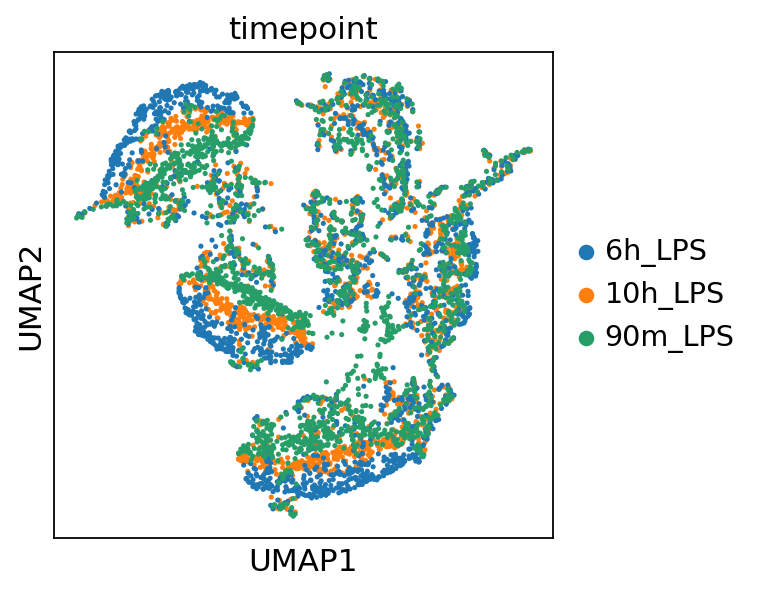

In [21]:
sc.pl.umap(new_adata,color='timepoint') # plot UMAP of gene embeddings colored by timepoint

Gene programs are identified by applying Leiden clustering to the gene embedding space, with each resulting cluster representing a coherent gene program.

In [22]:
sc.tl.leiden(new_adata,resolution=1,key_added='r1') # cluster gene embeddings

/tmp/ipykernel_632974/172354348.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(new_adata,resolution=1,key_added='r1') # cluster gene embeddings


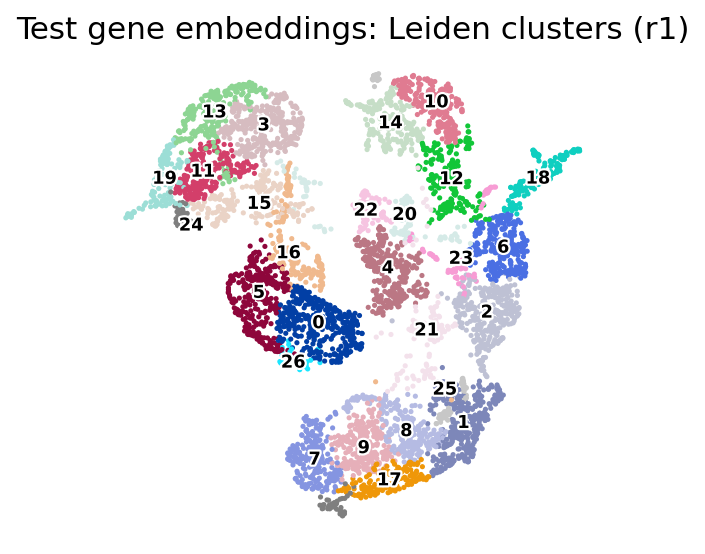

How many points in each cluster:
r1
0     394
1     334
10    250
11    229
12    219
13    213
14    204
15    184
16    182
17    155
18    146
19    132
2     330
20    115
21    103
22     87
23     81
24     77
25     62
26     43
3     323
4     317
5     316
6     268
7     263
8     260
9     251
Name: count, dtype: int64


In [23]:
# Each color = one Leiden program (r1). Numbers in the legend are cluster ids, not ranks.
sc.pl.umap(
    new_adata,
    color="r1",
    legend_loc="on data",
    legend_fontsize=8,
    legend_fontoutline=2,
    title="Test gene embeddings: Leiden clusters (r1)",
    frameon=False,
)

print("How many points in each cluster:")
print(new_adata.obs["r1"].astype(str).value_counts().sort_index())


For annotating gene programs, we recommend using predefined gene sets as guidance.


In [24]:
results = {}

for cluster in new_adata.obs['r1'].unique():
    cluster_genes = new_adata.obs.loc[new_adata.obs['r1'] == cluster, 'gene_symbol'].tolist()
    
    enr = gp.enrichr( # perform gene set enrichment analysis
        gene_list=cluster_genes,
        gene_sets= ['GO_Biological_Process_2025','Reactome_Pathways_2024'],
        
        organism='Human',              
        outdir=None,                  
        cutoff=0.5                     
    )
    
    results[cluster] = enr.results.sort_values('Adjusted P-value').head(5) # store top 5 results per cluster

As an example, we annotate cluster 6 as cytokine signaling, since it contains many interleukins and chemokines. Leiden IDs are from this full-atlas run. You can also calculate the z-score expression of any gene program of interest within the cell space.

In [25]:
# Force adata_full.var_names -> gene symbols (match new_adata.obs['gene_symbol']).
# NOTE: this h5ad's gene_name column is still Ensembl IDs — always map via Geneformer dict.
if "ensembl_to_symbol" not in globals():
    with open(GENE_NAME_ID_DICT, "rb") as f:
        symbol_to_ensembl = pickle.load(f)
    ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

if "ensembl_id" in adata_full.var.columns:
    ids = adata_full.var["ensembl_id"].astype(str)
elif "gene_ids-0" in adata_full.var.columns:
    ids = adata_full.var["gene_ids-0"].astype(str)
else:
    ids = pd.Index(adata_full.var_names.astype(str))

adata_full.var["ensembl_id"] = ids.values
adata_full.var["gene_symbol"] = [ensembl_to_symbol.get(g, g) for g in ids]
adata_full.var_names = adata_full.var["gene_symbol"].astype(str).values
adata_full.var_names_make_unique()

n_mapped = int((~pd.Index(adata_full.var_names).str.startswith("ENSG")).sum())
print("adata_full var_names (symbols):", list(adata_full.var_names[:5]))
print(f"Non-Ensembl var_names: {n_mapped}/{adata_full.n_vars}")
assert n_mapped > 0, "Symbol mapping failed — check GENE_NAME_ID_DICT / ensembl_to_symbol"


adata_full var_names (symbols): ['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'MMP23B']
Non-Ensembl var_names: 1855/1856


In [26]:
# Why cluster 6? Why IL1B / CXCL8 / ... ?
# Run this AFTER: new_adata, leiden (r1), and Enrichr (results = {}).

print("=" * 60)
print("1) WHO CHOSE 6?")
print("   The notebook author typed '6' in cluster_map. Leiden did not.")
print("   We only CHECK whether box 6 looks like cytokines in THIS run.")
print("=" * 60)

r1 = new_adata.obs["r1"].astype(str)
example_id = "6"
if example_id not in set(r1):
    example_id = sorted(set(r1), key=lambda x: int(x) if str(x).isdigit() else x)[0]
    print("Cluster 6 is missing in this run. Using", example_id, "instead.")

print("\nGenes sitting in box", example_id, "(first 15 unique):")
print(list(new_adata.obs.loc[r1 == example_id, "gene_symbol"].unique()[:15]))

key = next(k for k in results if str(k) == example_id)
print("\nEnrichr for box", example_id, "(this is the evidence for naming it):")
display(results[key].head(5))

print("\nOther boxes whose Enrichr text mentions cytokine/chemokine/interleukin:")
for cluster, df in results.items():
    if "Term" not in getattr(df, "columns", []):
        continue
    blob = " ".join(df["Term"].astype(str).str.lower())
    if any(w in blob for w in ["cytokine", "chemokine", "interleukin"]):
        top = str(df.iloc[0]["Term"]) if len(df) else ""
        mark = "  <-- tutorial uses this" if str(cluster) == "6" else ""
        print(f"  cluster {cluster}: {top}{mark}")

print("\n" + "=" * 60)
print("2) WHO CHOSE IL1B, CXCL8, ...?")
print("   Not Enrichr and not Leiden. The paper/tutorial highlight list")
print("   of famous LPS cytokine genes, to DRAW on the UMAP.")
print("=" * 60)

highlight_genes = ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R", "CXCL8", "CXCL3", "CXCL9"]
sub = new_adata.obs[new_adata.obs["gene_symbol"].str.upper().isin(highlight_genes)].copy()
sub["r1"] = sub["r1"].astype(str)
print("\nWhere those highlight genes actually landed (gene x time -> r1):")
display(sub[["gene_symbol", "timepoint", "r1"]].sort_values(["gene_symbol", "timepoint"]))
print("Count of highlight points per cluster:")
print(sub["r1"].value_counts())
in6 = sub.loc[sub["r1"] == "6", "gene_symbol"].str.upper().unique().tolist()
print("\nHighlight genes that ARE in box 6:", in6)
print("Highlight genes that are NOT in box 6:", sorted(set(highlight_genes) - set(in6)))


1) WHO CHOSE 6?
   The notebook author typed '6' in cluster_map. Leiden did not.
   We only CHECK whether box 6 looks like cytokines in THIS run.

Genes sitting in box 6 (first 15 unique):
['RUNX3', 'CSF3R', 'SLC1A7', 'CD160', 'LMNA', 'FCRL3', 'SH2D1B', 'PRDX6', 'RGS2', 'GPR25', 'BTG2', 'G0S2', 'ID2', 'CD207', 'IL18RAP']

Enrichr for box 6 (this is the evidence for naming it):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
1042,Reactome_Pathways_2024,Immune System,35/2150,3.471913e-11,1.454732e-08,0,0,4.747808,114.344915,ITGB1;APP;CSF3R;C5AR1;FPR1;F13A1;CBLB;PTPRJ;CF...
1043,Reactome_Pathways_2024,Neutrophil Degranulation,13/478,5.291714e-07,1.108614e-04,0,0,6.469380,93.495185,GSN;SLC11A1;C5AR1;FPR1;MCEMP1;PTPRJ;CFP;IQGAP2...
1044,Reactome_Pathways_2024,Cytokine Signaling in Immune System,16/776,9.514455e-07,1.328852e-04,0,0,4.975439,68.985866,ITGB1;APP;CSF3R;FPR1;F13A1;PTPRJ;TUBB4B;IFIT3;...
1045,Reactome_Pathways_2024,Innate Immune System,19/1149,2.224006e-06,2.329647e-04,0,0,4.046823,52.674262,APP;GSN;KLRC2;SLC11A1;C5AR1;FPR1;MCEMP1;PTPRJ;...
1046,Reactome_Pathways_2024,Signaling by Interleukins,11/452,1.205969e-05,1.010602e-03,0,0,5.644729,63.930185,ITGB1;APP;HCK;CSF3R;IL18RAP;IL2RA;IL2RB;BCL2;F...



Other boxes whose Enrichr text mentions cytokine/chemokine/interleukin:
  cluster 21: Immune System
  cluster 10: Calcium-Mediated Signaling (GO:0019722)
  cluster 1: Interleukin-4 and Interleukin-13 Signaling
  cluster 18: Immune System
  cluster 6: Immune System  <-- tutorial uses this
  cluster 4: Immune System

2) WHO CHOSE IL1B, CXCL8, ...?
   Not Enrichr and not Leiden. The paper/tutorial highlight list
   of famous LPS cytokine genes, to DRAW on the UMAP.

Where those highlight genes actually landed (gene x time -> r1):


,gene_symbol,timepoint,r1
CXCL3_6h_LPS,CXCL3,6h_LPS,6
CXCL3_10h_LPS,CXCL3,10h_LPS,6
CXCL3_90m_LPS,CXCL3,90m_LPS,21
CXCL8_6h_LPS,CXCL8,6h_LPS,4
CXCL8_10h_LPS,CXCL8,10h_LPS,4
CXCL8_90m_LPS,CXCL8,90m_LPS,21
CXCL9_6h_LPS,CXCL9,6h_LPS,1
CXCL9_10h_LPS,CXCL9,10h_LPS,1
CXCL9_90m_LPS,CXCL9,90m_LPS,20
IL1B_6h_LPS,IL1B,6h_LPS,2


Count of highlight points per cluster:
r1
4     8
21    5
12    2
2     2
17    2
6     2
1     2
20    1
Name: count, dtype: int64

Highlight genes that ARE in box 6: ['CXCL3']
Highlight genes that are NOT in box 6: ['CXCL8', 'CXCL9', 'IL1B', 'IL1RN', 'IL32', 'IL7R', 'PTX3']


In [27]:
# Score cluster 6 on expression space (var_names must be symbols — run cell above first)
genes_cluster_6 = list(
    dict.fromkeys(new_adata[new_adata.obs["r1"] == "6"].obs["gene_symbol"])
)
genes_present = [g for g in genes_cluster_6 if g in adata_full.var_names]

# Fallback: if var_names are still Ensembl, resolve symbols -> Ensembl
if not genes_present:
    if "symbol_to_ensembl" not in globals():
        with open(GENE_NAME_ID_DICT, "rb") as f:
            symbol_to_ensembl = pickle.load(f)
    genes_present = [
        symbol_to_ensembl[g]
        for g in genes_cluster_6
        if g in symbol_to_ensembl and symbol_to_ensembl[g] in adata_full.var_names
    ]

print(f"Cluster 6 genes in adata_full: {len(genes_present)}/{len(genes_cluster_6)}")
print("example cluster genes:", genes_cluster_6[:5])
print("example adata_full genes:", list(adata_full.var_names[:5]))
assert genes_present, (
    "No cluster genes found in adata_full — re-run the symbol-alignment cell above."
)

sc.tl.score_genes(
    adata_full, gene_list=genes_present, score_name="Cytokine Signaling"
)


Cluster 6 genes in adata_full: 97/97
example cluster genes: ['RUNX3', 'CSF3R', 'SLC1A7', 'CD160', 'LMNA']
example adata_full genes: ['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'MMP23B']


In [28]:
cluster_map = {
    '6': 'Cytokine Signaling',
}

new_adata.obs['MoA'] = new_adata.obs['r1'].map(cluster_map).fillna('Others') # annotate clusters with MoA labels

Visualize the UMAP and highlight the cluster containing the genes of interest.

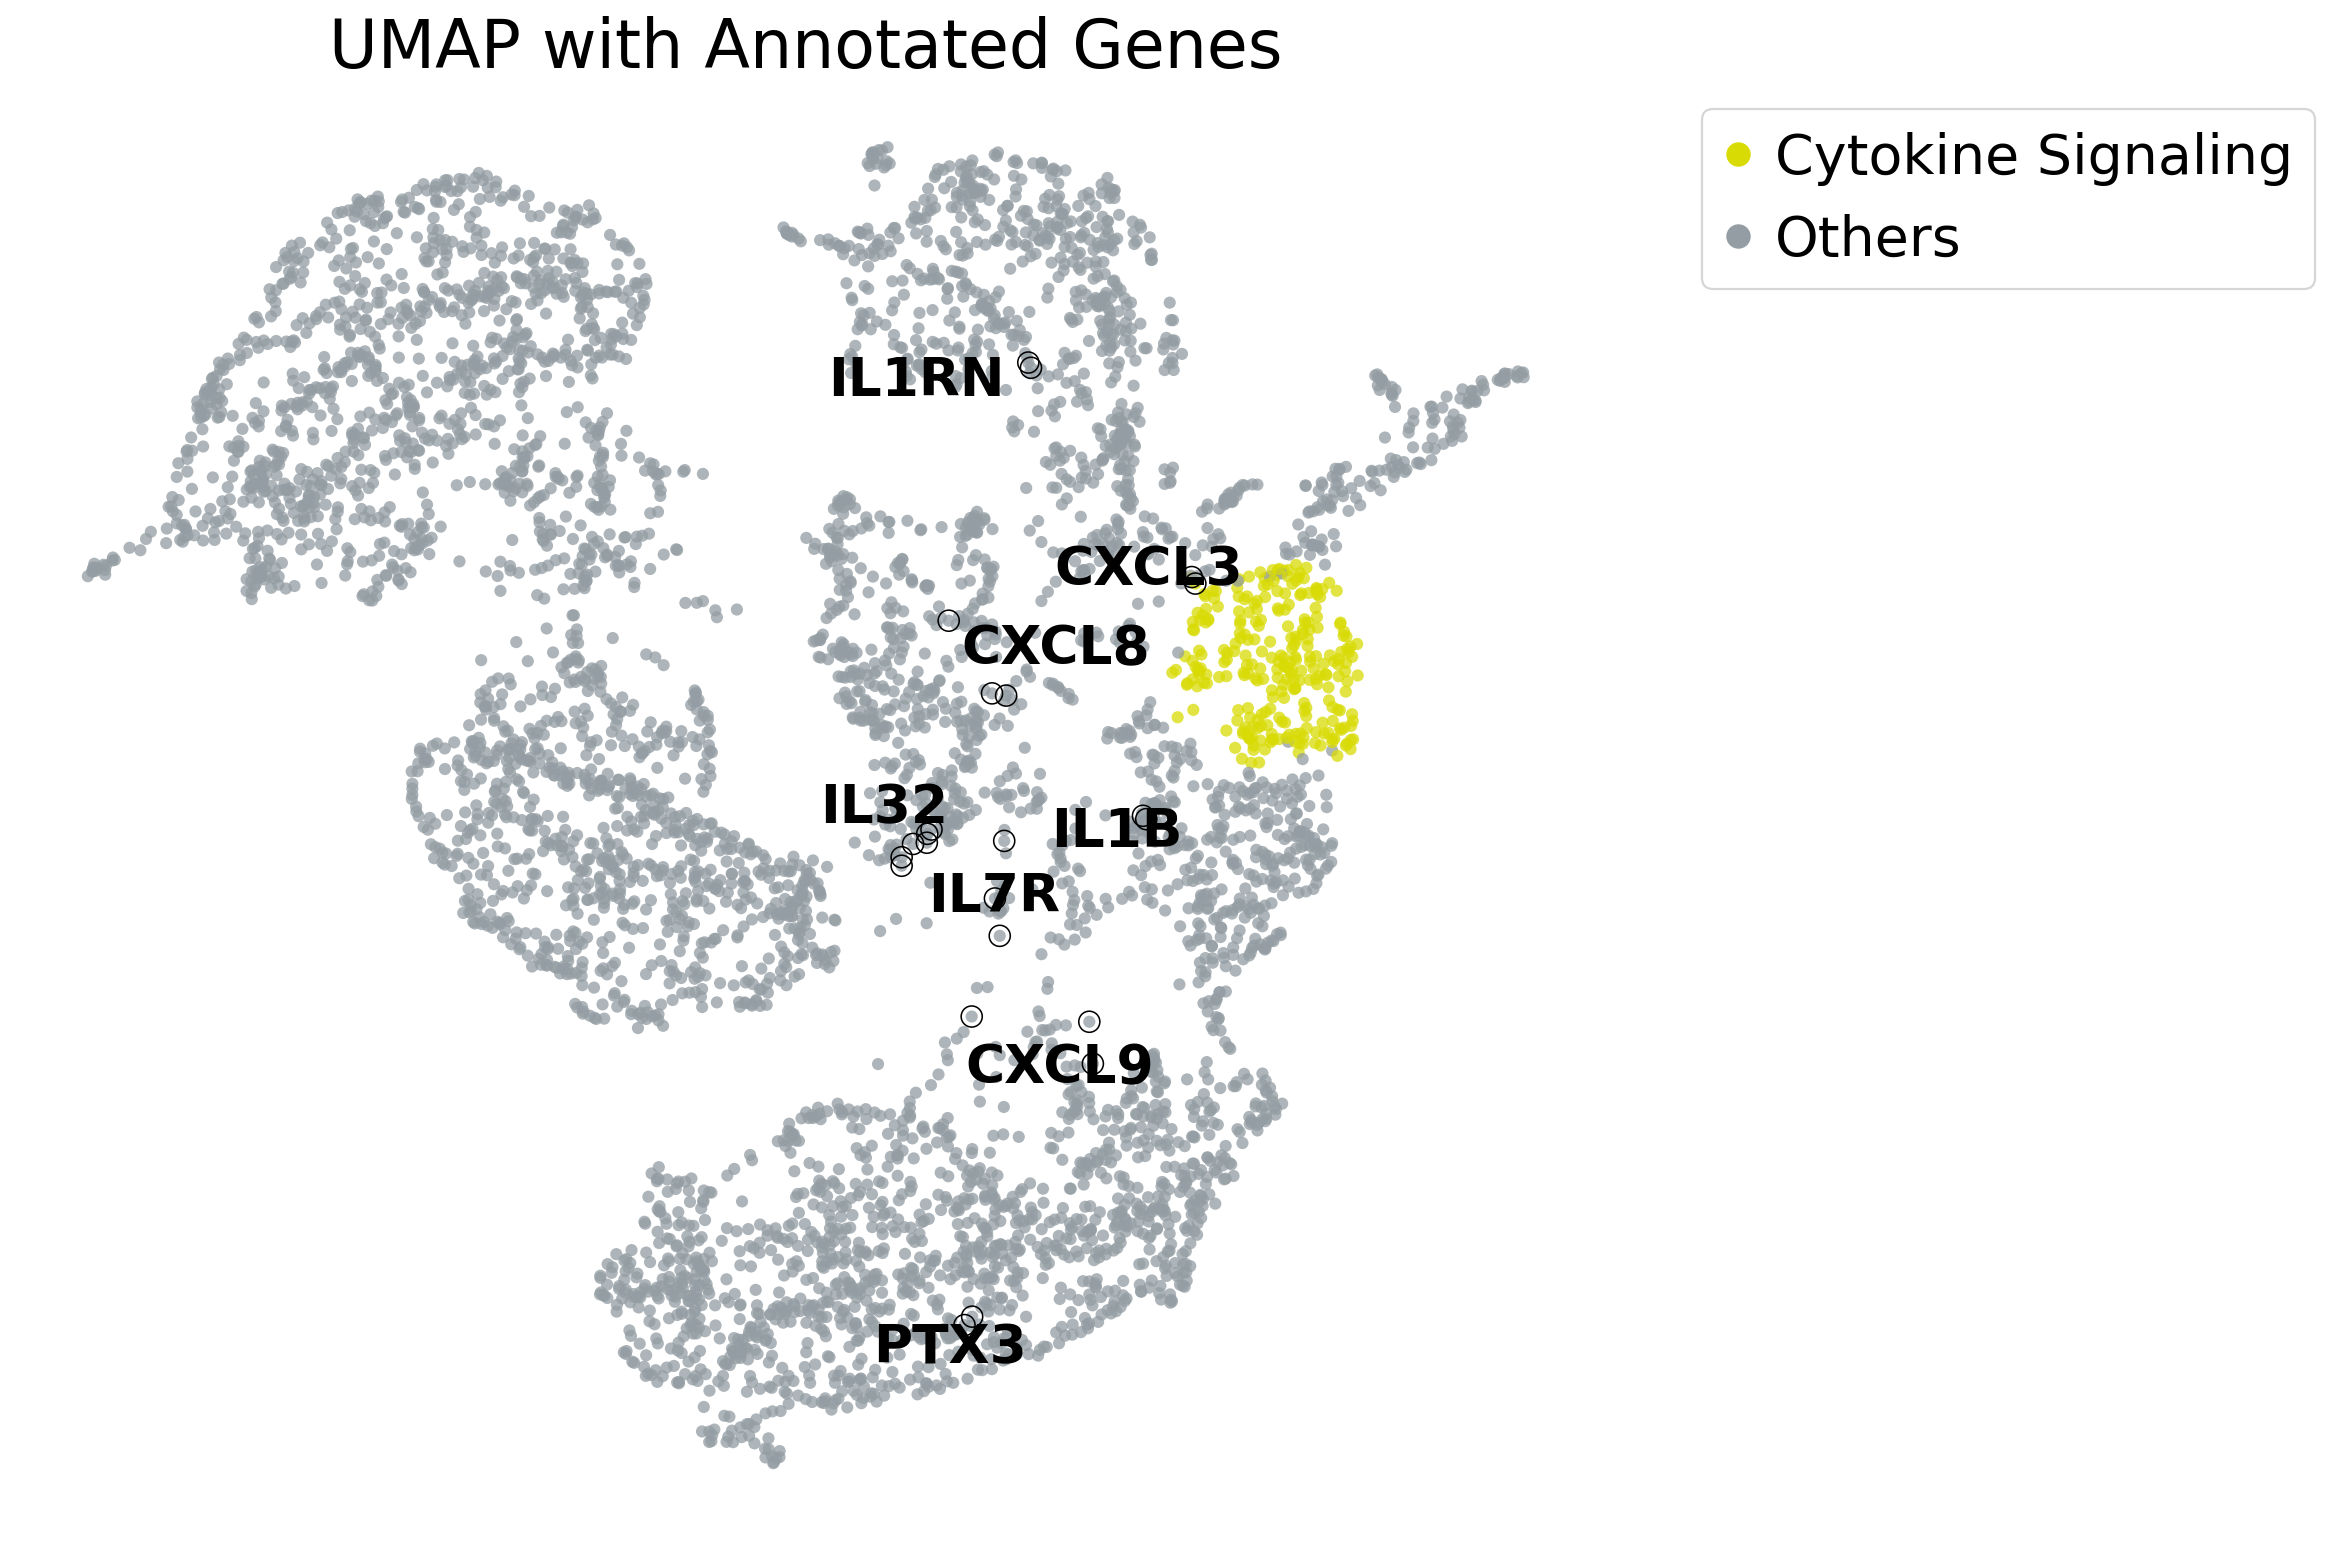

In [29]:
highlight_dict = {
    'Cytokine Signaling': ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R","CXCL8","CXCL3","CXCL9"],
}
custom_colors = {
    'Cytokine Signaling': '#d9db05',
    'Others': '#939da3',
}


umap_df = pd.DataFrame(new_adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
umap_df['MoA']  = new_adata.obs['MoA'].astype(str).values          
umap_df['gene'] = new_adata.obs['gene_symbol'].astype(str).values  

present = sorted(umap_df['MoA'].unique())
palette = {k: custom_colors.get(k, '#939da3') for k in present}

plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=umap_df, x='UMAP1', y='UMAP2', hue='MoA',
    palette=palette, linewidth=0, alpha=0.75, s=30
)
plt.title('UMAP with Annotated Genes', fontsize=30)
plt.xlabel('UMAP1', fontsize=24); plt.ylabel('UMAP2', fontsize=24)
plt.axis('off'); plt.grid(False)

texts = []
for moa, genes in highlight_dict.items():
    for gene in genes:
        mask = (umap_df['gene'].str.upper() == gene.upper()) & (umap_df['MoA'] == moa)
        if not mask.any():
            mask = (umap_df['gene'].str.upper() == gene.upper())

        if mask.any():
            plt.scatter(
                umap_df.loc[mask, 'UMAP1'],
                umap_df.loc[mask, 'UMAP2'],
                s=90, linewidths=0.7, edgecolors='k', facecolors='none', zorder=5
            )

            x_med = umap_df.loc[mask, 'UMAP1'].median()
            y_med = umap_df.loc[mask, 'UMAP2'].median()
            jitter_x = x_med - 1.0 if gene == "IL1RN" else x_med + np.random.uniform(-0.5, 0.5)
            jitter_y = y_med + np.random.uniform(-0.5, 0.5)

            texts.append(
                plt.text(jitter_x, jitter_y, gene,
                         fontsize=24, fontweight='bold', ha='center', va='center', zorder=6)
            )

adjust_text(
    texts,
    expand_points=(15, 15),
    expand_text=(10, 10),
    force_points=5.0,
    force_text=5.0,
    pad=10.0,
    only_move={'points': 'xy', 'text': 'xy'},
    autoalign='xy',
    lim=1500
)

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=palette[k], markersize=12) for k in present]
plt.legend(handles=handles, labels=present, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=25)

plt.tight_layout()
plt.savefig(FIG_DIR / "umap_highlight_gene_symbol.png", dpi=600, bbox_inches="tight")
plt.show()


Optionally, you may visualize the z-score expression of a gene program of interest, stratified by cell type or another relevant variable.

/tmp/ipykernel_632974/2005851278.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cell_type_harmonized')['Cytokine Signaling']
/tmp/ipykernel_632974/2005851278.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


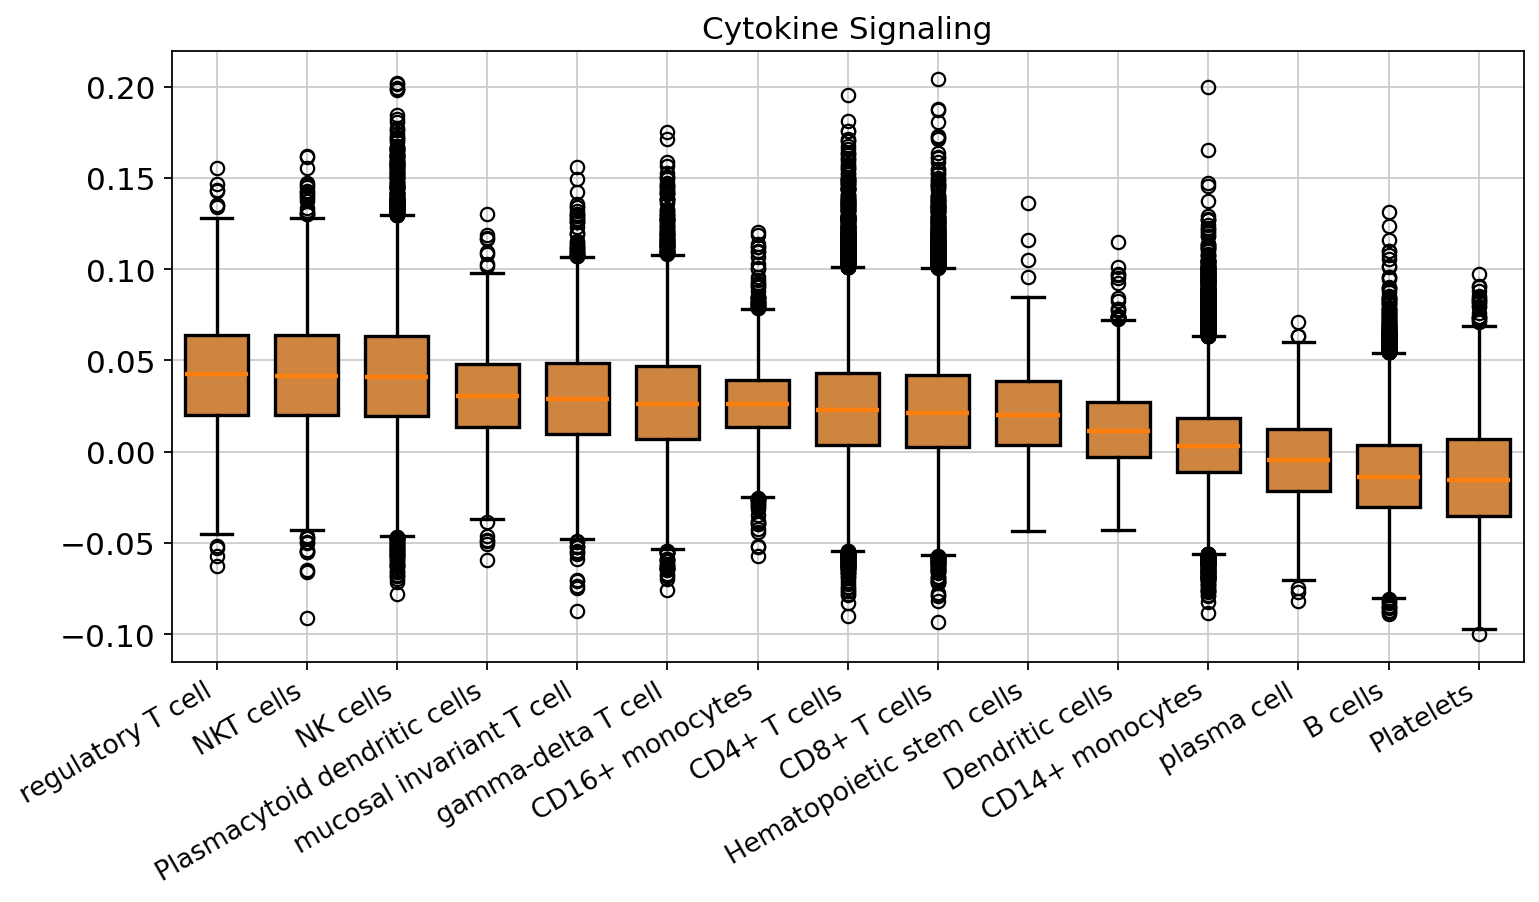

In [30]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})


df = adata_full.obs[['cell_type_harmonized', 'Cytokine Signaling']].dropna()

ordered_cell_types = (
    df.groupby('cell_type_harmonized')['Cytokine Signaling']
      .median()
      .sort_values(ascending=False)
      .index.tolist()
)

data = [df.loc[df['cell_type_harmonized'] == ct, 'Cytokine Signaling'].values
        for ct in ordered_cell_types]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    data,
    patch_artist=True,  
    labels=ordered_cell_types,
    widths=0.7,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.5)
)

for box in bp['boxes']:
    box.set_facecolor('peru')

ax.set_title('Cytokine Signaling')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "cytokine_signaling_boxplot.pdf", dpi=600, bbox_inches="tight", format="pdf")
plt.show()


We subset the data to the myeloid lineage, as the gene program was highly enriched in these cells. We then examined the gene program scores within the myeloid population across different timepoints.

In [31]:
myeloids = adata_full[adata_full.obs['cell_type_harmonized'].isin(['CD14+ monocytes','CD16+ monocytes','Dendritic cells'])].copy()

In [32]:
s = myeloids.obs['time_after_LPS'].astype('category')

rename_map = {
    '90m_LPS': '90m',
    '6h_LPS':  '6h',
    '10h_LPS': '10h',
    'normal':  'normal',
}
s = s.cat.rename_categories({k: v for k, v in rename_map.items() if k in s.cat.categories})

new_order = ['normal', '90m', '6h', '10h']
s = s.cat.reorder_categories(new_order, ordered=True)

myeloids.obs['time_after_LPS'] = s

palette = {
    'normal': '#d62728',
    '90m':    '#2ca02c',
    '6h':     '#1f77b4',
    '10h':    '#ff7f0e',
}
myeloids.uns['time_after_LPS_colors'] = [palette[c] for c in s.cat.categories]

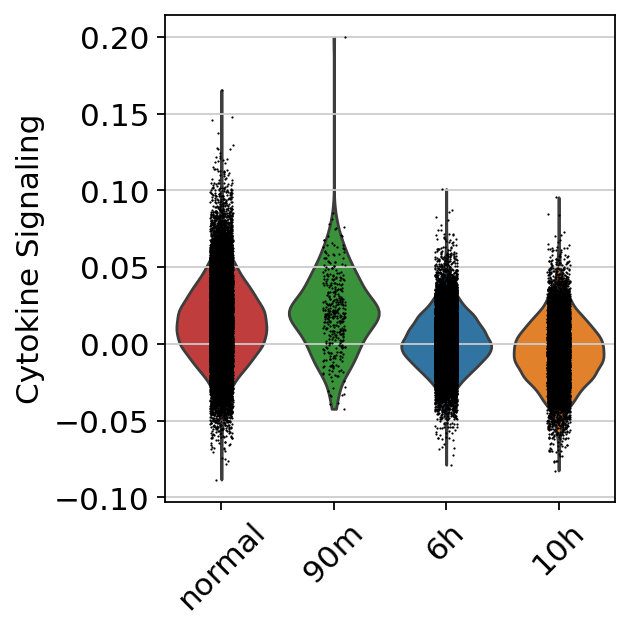

In [33]:
sc.pl.violin(myeloids,keys='Cytokine Signaling',groupby='time_after_LPS',rotation=45,save='myeloids.png') # plot violin plot of Cytokine Signaling score in myeloid cells